In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_selection import f_classif
from sklearn.metrics import (accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix,
    roc_curve, roc_auc_score, classification_report)

In [2]:
df = pd.read_csv("F:\\01. The Data Psychology\\4. New_Machine_Learning\\2. Logistic Regression\\heart_attack_dataset.csv")

In [3]:
df.head()

,Age,Cholesterol,BloodPressure,BMI,Smoking,Diabetes,ExerciseHours,FamilyHistory,AlcoholUnits,StressLevel,HeartAttack
0,58,183,175,22.7,1,1,0.5,0,17.7,1,1
1,71,241,177,20.7,1,1,0.5,0,17.9,1,1
2,48,244,142,35.8,1,0,6.9,0,6.7,4,1
3,34,221,107,38.6,1,1,4.6,1,12.3,6,1
4,62,188,139,25.2,0,1,2.3,1,18.5,9,1


In [4]:
df.shape

(1000, 11)

In [5]:
df.isnull().sum()

Age              0
Cholesterol      0
BloodPressure    0
BMI              0
Smoking          0
Diabetes         0
ExerciseHours    0
FamilyHistory    0
AlcoholUnits     0
StressLevel      0
HeartAttack      0
dtype: int64

In [6]:
df.duplicated().sum()

0

In [7]:
df.dtypes

Age                int64
Cholesterol        int64
BloodPressure      int64
BMI              float64
Smoking            int64
Diabetes           int64
ExerciseHours    float64
FamilyHistory      int64
AlcoholUnits     float64
StressLevel        int64
HeartAttack        int64
dtype: object

In [8]:
X = df.drop('HeartAttack', axis=1)  # all columns except target
y = df['HeartAttack']               # only target column

In [9]:
X.head()

,Age,Cholesterol,BloodPressure,BMI,Smoking,Diabetes,ExerciseHours,FamilyHistory,AlcoholUnits,StressLevel
0,58,183,175,22.7,1,1,0.5,0,17.7,1
1,71,241,177,20.7,1,1,0.5,0,17.9,1
2,48,244,142,35.8,1,0,6.9,0,6.7,4
3,34,221,107,38.6,1,1,4.6,1,12.3,6
4,62,188,139,25.2,0,1,2.3,1,18.5,9


In [10]:
y

0      1
1      1
2      1
3      1
4      1
      ..
995    1
996    0
997    1
998    1
999    0
Name: HeartAttack, Length: 1000, dtype: int64

In [11]:
f_scores, p_values = f_classif(X, y)

In [12]:
feature_scores = pd.DataFrame({
    'Feature' : X.columns,
    'F-Score' : f_scores.round(2),
    'P-Value' : p_values.round(4),
    'Keep'    : ['Yes' if p < 0.05 else 'No' for p in p_values]
}).sort_values('F-Score', ascending=False)

In [13]:
print(feature_scores.to_string(index=False))

      Feature  F-Score  P-Value Keep
          Age   206.36   0.0000  Yes
  Cholesterol    95.52   0.0000  Yes
          BMI    73.62   0.0000  Yes
BloodPressure    57.43   0.0000  Yes
ExerciseHours    30.62   0.0000  Yes
      Smoking    23.67   0.0000  Yes
 AlcoholUnits    15.14   0.0001  Yes
     Diabetes    12.07   0.0005  Yes
  StressLevel    11.16   0.0009  Yes
FamilyHistory     7.75   0.0055  Yes


In [14]:
# Keep only significant features
selected = feature_scores[feature_scores['Keep'] == 'Yes']['Feature'].tolist()

X = X[selected]

In [47]:
selected

['Age',
 'Cholesterol',
 'BMI',
 'BloodPressure',
 'ExerciseHours',
 'Smoking',
 'AlcoholUnits',
 'Diabetes',
 'StressLevel',
 'FamilyHistory']

In [16]:
X.head()

,Age,Cholesterol,BMI,BloodPressure,ExerciseHours,Smoking,AlcoholUnits,Diabetes,StressLevel,FamilyHistory
0,58,183,22.7,175,0.5,1,17.7,1,1,0
1,71,241,20.7,177,0.5,1,17.9,1,1,0
2,48,244,35.8,142,6.9,1,6.7,0,4,0
3,34,221,38.6,107,4.6,1,12.3,1,6,1
4,62,188,25.2,139,2.3,0,18.5,1,9,1


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y
)

In [18]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((800, 10), (200, 10), (800,), (200,))

In [19]:
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [20]:
print("Scaling done")
print(f"Train mean (first 3): {X_train_scaled[:, 0].mean():.3f}")
print(f"Train std  (first 3): {X_train_scaled[:, 0].std():.3f}")
print()

Scaling done
Train mean (first 3): -0.000
Train std  (first 3): 1.000



In [21]:
model = LogisticRegression(max_iter=1000, random_state=42)

model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [22]:
print("Model trained with default parameters")
print(f"  C      : {model.C}")
print(f"  Solver : {model.solver}")
print()


Model trained with default parameters
  C      : 1.0
  Solver : lbfgs



In [23]:
y_pred       = model.predict(X_test_scaled)

y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

In [24]:
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred):.4f}")
print(f"AUC Score : {roc_auc_score(y_test, y_pred_proba):.4f}")

Accuracy  : 0.9350
Precision : 0.9437
Recall    : 0.9742
F1 Score  : 0.9587
AUC Score : 0.9838


In [25]:
print(confusion_matrix(y_test, y_pred))

[[ 36   9]
 [  4 151]]


In [26]:
print(classification_report(y_test, y_pred,
      target_names=['No Attack', 'Heart Attack']))

              precision    recall  f1-score   support

   No Attack       0.90      0.80      0.85        45
Heart Attack       0.94      0.97      0.96       155

    accuracy                           0.94       200
   macro avg       0.92      0.89      0.90       200
weighted avg       0.93      0.94      0.93       200



In [27]:
fpr1, tpr1, _ = roc_curve(y_test, y_pred_proba)
auc1          = roc_auc_score(y_test, y_pred_proba)

In [28]:
# C            → regularization strength (small=simple, large=complex)
# solver       → optimization algorithm
# max_iter     → max gradient descent steps
# class_weight → handle imbalanced dataset

In [29]:
param_grid = {
    'C'            : [0.01, 0.1, 1, 10, 100],
    'solver'       : ['lbfgs', 'liblinear'],
    'max_iter'     : [500, 1000],
    'class_weight' : [None, 'balanced']
}


In [30]:
grid = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid,
    cv      = 5,          # 5-fold cross validation
    scoring = 'roc_auc',  # optimize for AUC
    n_jobs  = -1          # use all CPU cores
)


In [31]:
grid.fit(X_train_scaled, y_train)

print(f"Best Parameters : {grid.best_params_}")
print(f"Best CV AUC     : {grid.best_score_:.4f}")

Best Parameters : {'C': 100, 'class_weight': 'balanced', 'max_iter': 500, 'solver': 'lbfgs'}
Best CV AUC     : 0.9892


In [32]:
best_model = grid.best_estimator_

In [33]:
best_model

,penalty,'l2'
,dual,False
,tol,0.0001
,C,100
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,500
,multi_class,'deprecated'


In [34]:
y_pred2       = best_model.predict(X_test_scaled)
y_pred_proba2 = best_model.predict_proba(X_test_scaled)[:, 1]

print(f"Accuracy  : {accuracy_score(y_test, y_pred2):.4f}")
print(f"Precision : {precision_score(y_test, y_pred2):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred2):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred2):.4f}")
print(f"AUC Score : {roc_auc_score(y_test, y_pred_proba2):.4f}")

Accuracy  : 0.9500
Precision : 0.9801
Recall    : 0.9548
F1 Score  : 0.9673
AUC Score : 0.9848


In [35]:
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred2))
print()
print("Classification Report:")
print(classification_report(y_test, y_pred2,
      target_names=['No Attack', 'Heart Attack']))

# ROC Curve — After Tuning
fpr2, tpr2, _ = roc_curve(y_test, y_pred_proba2)
auc2          = roc_auc_score(y_test, y_pred_proba2)


Confusion Matrix:
[[ 42   3]
 [  7 148]]

Classification Report:
              precision    recall  f1-score   support

   No Attack       0.86      0.93      0.89        45
Heart Attack       0.98      0.95      0.97       155

    accuracy                           0.95       200
   macro avg       0.92      0.94      0.93       200
weighted avg       0.95      0.95      0.95       200



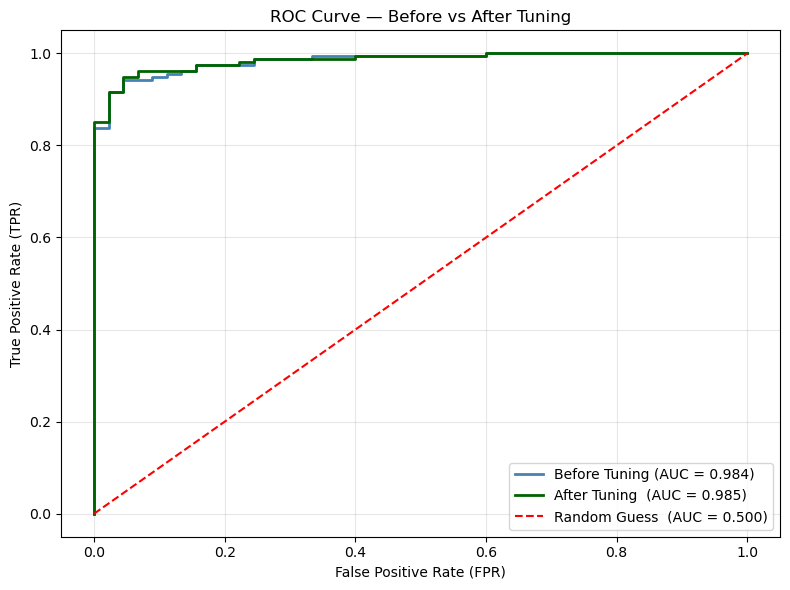

ROC curve saved



In [37]:
plt.figure(figsize=(8, 6))

plt.plot(fpr1, tpr1, color='steelblue', lw=2,
         label=f'Before Tuning (AUC = {auc1:.3f})')

plt.plot(fpr2, tpr2, color='darkgreen', lw=2,
         label=f'After Tuning  (AUC = {auc2:.3f})')

plt.plot([0, 1], [0, 1], 'r--', lw=1.5,
         label='Random Guess  (AUC = 0.500)')

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve — Before vs After Tuning')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print("ROC curve saved")
print()

In [38]:
joblib.dump(best_model, 'best_model.pkl')
joblib.dump(scaler,     'best_scaler.pkl')

['best_scaler.pkl']

In [ ]:
loaded_model  = joblib.load('best_model.pkl')
loaded_scaler = joblib.load('best_scaler.pkl')

In [39]:
new_data = pd.DataFrame({
    'Age'           : [22,  45,  55,  63,  70 ],
    'Cholesterol'   : [170, 210, 280, 320, 345 ],
    'BloodPressure' : [108, 130, 150, 172, 175 ],
    'BMI'           : [21.5, 27.0, 31.5, 38.0, 42.0],
    'Smoking'       : [0,   0,   1,   1,   1  ],
    'Diabetes'      : [0,   0,   0,   1,   1  ],
    'ExerciseHours' : [8.0, 4.5, 2.0, 1.0, 0.5],
    'FamilyHistory' : [0,   1,   0,   1,   1  ],
    'AlcoholUnits'  : [2.0, 8.0, 12.0, 17.0, 19.0],
    'StressLevel'   : [2,   5,   6,   8,   9  ]
})


In [40]:
new_data

,Age,Cholesterol,BloodPressure,BMI,Smoking,Diabetes,ExerciseHours,FamilyHistory,AlcoholUnits,StressLevel
0,22,170,108,21.5,0,0,8.0,0,2.0,2
1,45,210,130,27.0,0,0,4.5,1,8.0,5
2,55,280,150,31.5,1,0,2.0,0,12.0,6
3,63,320,172,38.0,1,1,1.0,1,17.0,8
4,70,345,175,42.0,1,1,0.5,1,19.0,9


In [42]:
# keep only selected features (same as training)
new_data = new_data[selected]

# scale using loaded scaler (never re-fit on new data)
new_scaled = scaler.transform(new_data)

In [46]:
selected

['Age',
 'Cholesterol',
 'BMI',
 'BloodPressure',
 'ExerciseHours',
 'Smoking',
 'AlcoholUnits',
 'Diabetes',
 'StressLevel',
 'FamilyHistory']

In [43]:
new_scaled

array([[-1.61042824, -1.33503864, -1.27867903, -0.67444922,  1.09702804,
        -0.94643256, -1.35321067, -1.0100505 , -1.19490705, -1.08347268],
       [-0.28224   , -0.64782639, -0.57121383,  0.07650329, -0.13910964,
        -0.94643256, -0.32693344, -1.0100505 , -0.18405865,  0.92295821],
       [ 0.29523315,  0.55479504,  0.00762133,  0.75918739, -1.02206512,
         1.05659932,  0.35725138, -1.0100505 ,  0.15289082, -1.08347268],
       [ 0.75721166,  1.24200728,  0.84371656,  1.5101399 , -1.37524731,
         1.05659932,  1.2124824 ,  0.9900495 ,  0.82678976,  0.92295821],
       [ 1.16144286,  1.67151494,  1.35823671,  1.61254251, -1.55183841,
         1.05659932,  1.55457481,  0.9900495 ,  1.16373923,  0.92295821]])

In [44]:
predictions  = best_model.predict(new_scaled)
probabilities = best_model.predict_proba(new_scaled)[:, 1]

In [45]:
print(f"{'Patient':<10} {'Probability':<15} {'Prediction'}")
print("-" * 40)
for i in range(len(predictions)):
    result = "HEART ATTACK" if predictions[i] == 1 else "NO ATTACK"
    print(f"Patient {i+1:<3} {probabilities[i]:<15.3f} {result}")

Patient    Probability     Prediction
----------------------------------------
Patient 1   0.000           NO ATTACK
Patient 2   0.024           NO ATTACK
Patient 3   1.000           HEART ATTACK
Patient 4   1.000           HEART ATTACK
Patient 5   1.000           HEART ATTACK
